# ANALISIS EXPLORATORIO DE DATOS

#### Importamos librerias

In [1]:
!{sys.executable} -m pip install -r requirements.txt

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
# Usamos sentence-transformers (gratis, corre local) para el esqueleto.
# Cuando definan el modelo de embeddings final, pueden cambiar esta función
# por la de OpenAI (text-embedding-3-small) sin tocar el resto del código.
!{sys.executable} -m pip install -q sentence-transformers chromadb langchain-text-splitters pandas numpy matplotlib tqdm


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
import uuid
import chromadb
import re
from utils.plot_functions import *
from utils.chunk_functions import *
from sentence_transformers import SentenceTransformer
import sys
import re
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import chromadb
from langchain_text_splitters import RecursiveCharacterTextSplitter

pd.set_option("display.max_colwidth", 120)

 
warnings.filterwarnings("ignore")

#### Inspeccionamos el dataset

In [7]:
df = pd.read_csv(r'C:\Users\renat\Documents\Facultad\5to año\Ciencia de Datos (1C)\Ciencia-de-Datos\src\data\Reviews.csv')

In [8]:
#Inspeccionamos las primeras 5 filas para hacernos una idea rápida del mismo.
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...


In [9]:
#Chequeo de columnas
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [10]:
#Buscamos si hay nulos
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Como estrategia para imputar los nulos, decidimos llenarlos con un valor predeterminado y no con por ejemplo, la moda ya que podría sesgar las columnas

In [11]:
df['ProfileName'] = df['ProfileName'].fillna('UNKNOWN_USER')
df['Summary'] = df['Summary'].fillna('NO SUMMARY')

In [12]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [13]:
df["Time"] = pd.to_datetime(df["Time"], unit="s")

In [14]:
#Obtenemos más descripción e información del DataFrame
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   Id                      568454 non-null  int64        
 1   ProductId               568454 non-null  str          
 2   UserId                  568454 non-null  str          
 3   ProfileName             568454 non-null  str          
 4   HelpfulnessNumerator    568454 non-null  int64        
 5   HelpfulnessDenominator  568454 non-null  int64        
 6   Score                   568454 non-null  int64        
 7   Time                    568454 non-null  datetime64[s]
 8   Summary                 568454 non-null  str          
 9   Text                    568454 non-null  str          
dtypes: datetime64[s](1), int64(4), str(5)
memory usage: 312.9 MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,568454
mean,284227.500000,1.743817,2.22881,4.183199,2011-01-28 23:16:44
min,1.000000,0.000000,0.00000,1.000000,1999-10-08 00:00:00
25%,142114.250000,0.000000,0.00000,4.000000,2010-04-15 00:00:00
50%,284227.500000,0.000000,1.00000,5.000000,2011-07-20 00:00:00
75%,426340.750000,2.000000,2.00000,5.000000,2012-03-26 00:00:00
max,568454.000000,866.000000,923.00000,5.000000,2012-10-26 00:00:00
std,164098.679298,7.636513,8.28974,1.310436,NaN


## Creamos Variables Auxiliares para los gráficos

In [15]:
# Calcula la cantidad de palabras que tiene cada texto en una columna y guarda ese resultado en una columna nueva
df["review_length"] = (
    df["Text"]
      .str.split()
      .str.len()
)

In [16]:
# Calcula la cantidad de palabras que tiene cada texto en la columna "Summary" (Resumen) y guarda el resultado en una nueva columna llamada "summary_length"
df["summary_length"] = (
    df["Summary"]
      .str.split()
      .str.len()
)

In [17]:
# Calcula un porcentaje o ratio de utilidad para cada reseña
df["helpfulness_ratio"] = (
    df["HelpfulnessNumerator"] /
    df["HelpfulnessDenominator"].replace(0,np.nan)
)

df["helpfulness_ratio"] = (
    df["helpfulness_ratio"]
    .fillna(0)
)

In [18]:
#Se encarga de fusionar el resumen y el texto principal de cada reseña para crear una sola columna con el texto completo
df["full_text"] = (df["Summary"].astype(str) + ". " + df["Text"].astype(str)).str.strip()

# EDA

#### Distribuciones Univariadas

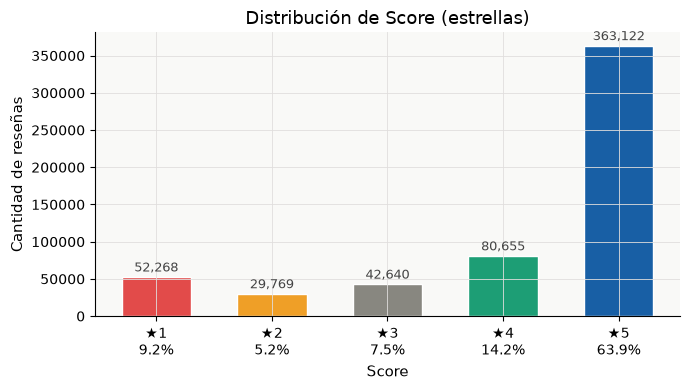

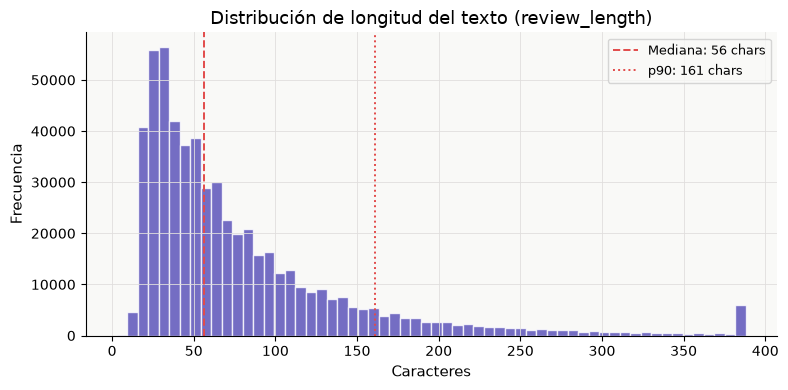

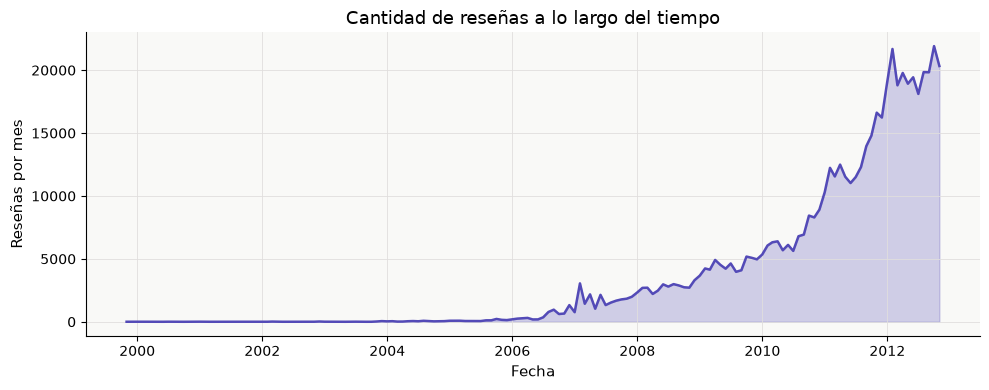

In [19]:
df_score = plot_score_distribution(df)
df_longitud_texto = plot_text_length_distribution(df)
df_grafico_3 = plot_reviews_over_time(df)

#### Variables Categóricas

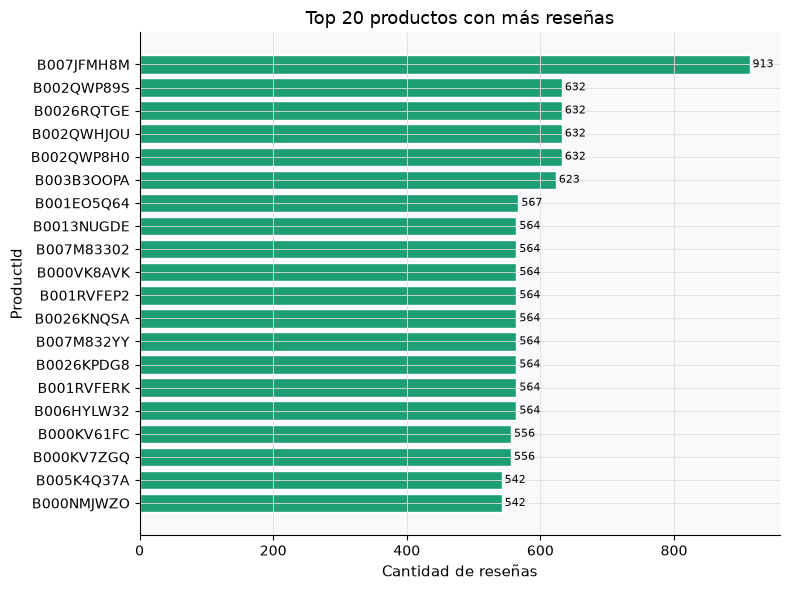

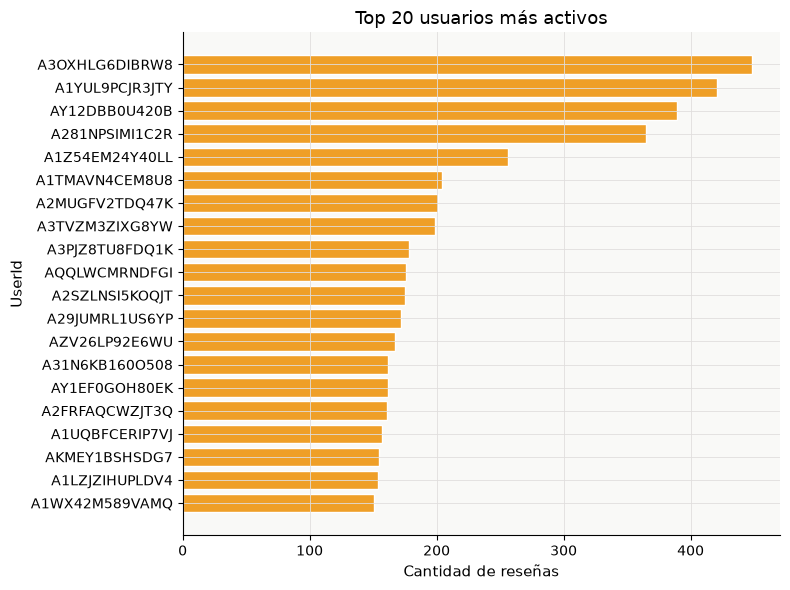

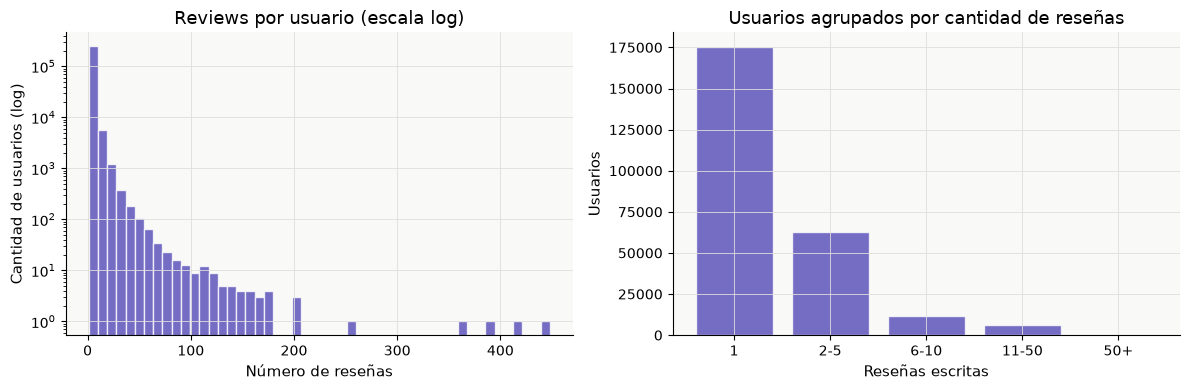

In [20]:
df_graf = plot_top_products(df)
df_graf_2 = plot_top_users(df)
df_graf_3 = plot_reviews_per_user_distribution(df)

#### Helpfulness

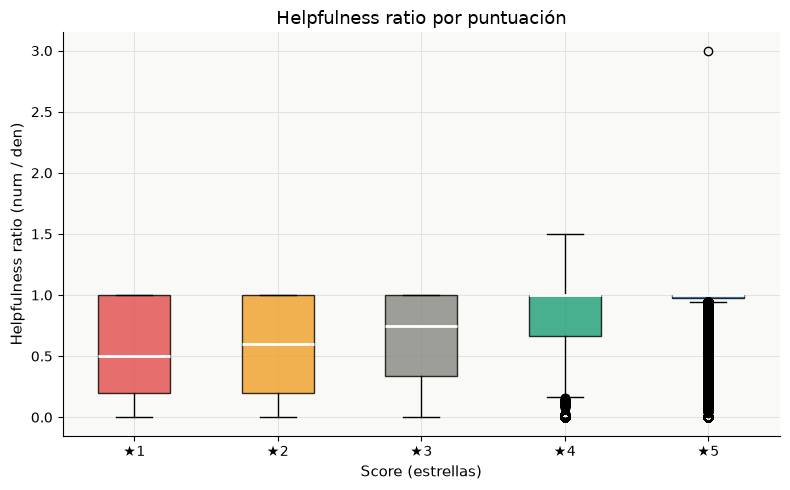

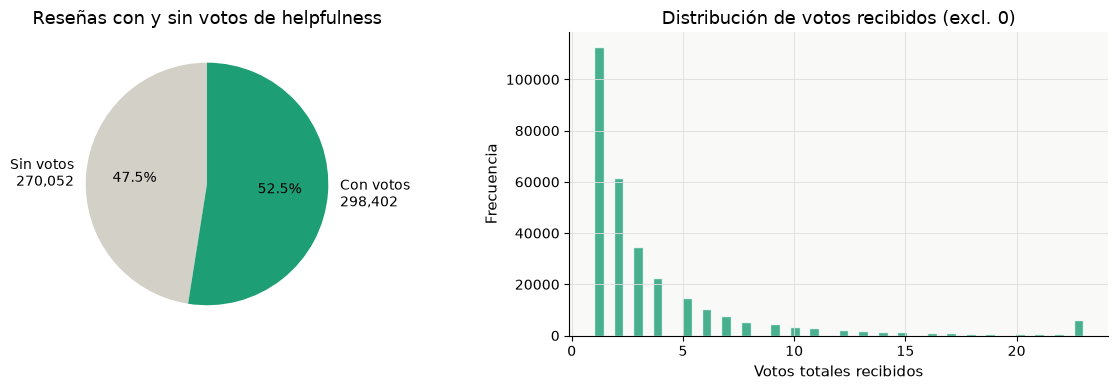

In [21]:
graficos_text = plot_helpfulness_ratio_by_score(df)
graficos_text_1 = plot_denominator_distribution(df)

Capa 1 (interna): chunkeás las reviews de cada producto para que el LLM tenga contexto suficiente y genere una buena descripción (esto es un RAG "de generación").

Paso 1 — Preparar el dataset para chunking (post-EDA)

Agrupar reviews por ProductId. Vas a ver que la cantidad de reviews por producto es muy dispar (esto ya lo viste en plot_top_products). Documentá cuántos productos tienen 1 sola review vs. cientos, porque eso condiciona la estrategia.
Limpiar texto: sacar HTML residual, normalizar mayúsculas/emojis si hay, pero sin perder info útil (sarcasmo, negaciones).
Decidir qué campos van a formar parte del "documento a chunkear": Summary + Text, quizás ponderado por Score y HelpfulnessNumerator.

Paso 2 — Definir el set de preguntas de prueba (golden set)
Necesitás esto antes de probar chunking, porque sin preguntas no podés medir nada:

Armá ~20-30 preguntas representativas de usuario final, en 2-3 categorías:

Preguntas sobre un producto puntual ("¿qué dicen del sabor del producto X?")
Preguntas comparativas/de descubrimiento ("recomendame un café orgánico suave")
Preguntas con filtros de negocio ("productos con score > 4 y muchas reviews")


Para cada pregunta, anotá manualmente cuál es el ProductId o chunk "correcto" esperado (ground truth). Esto es tu base para medir accuracy/recall después.

Paso 3 — Probar estrategias de chunking (sobre las reviews)
Probá al menos 3-4 variantes y documentá pros/contras:

Fixed-size / token-based (RecursiveCharacterTextSplitter de LangChain, chunk_size ~300-500 tokens, overlap 50-100).
Chunking por review individual (cada review = 1 chunk, con metadata de producto). Simple pero puede generar muchos chunks ruidosos para productos con pocas reviews cortas.
Agregación por producto con límite de tokens (concatenar reviews de un producto hasta un tope, luego cortar en varios chunks si no entra).
Chunking semántico (splitting por similitud de embeddings entre oraciones, ej. SemanticChunker de LangChain) — más caro pero potencialmente mejor calidad.

Paso 4 — Indexar y taggear cada chunk
Por cada chunk generá:

chunk_id único
embedding (elegí un modelo: text-embedding-3-small de OpenAI es barato y anda bien, o alternativas open-source tipo sentence-transformers si quieren costo cero)
metadata/tags: ProductId, Score promedio del chunk, HelpfulnessRatio, fecha, cantidad de reviews agregadas — esto es lo que van a usar en el paso 5 para filtrar sin depender del LLM.

Paso 5 — Definir métrica y comparar estrategias
Métricas típicas de retrieval (simples de calcular con tu golden set):

Recall@k / Hit Rate@k: ¿el chunk correcto aparece entre los top-k recuperados?
MRR (Mean Reciprocal Rank): qué tan arriba aparece el correcto.
Opcional más adelante: Precision/Faithfulness con RAGAS o el tutorial de LangSmith que ya tienen linkeado en el doc (punto 7), pero eso lo dejaría para cuando midan el retrieval final sobre descripciones, no en esta etapa interna.

Corré las mismas preguntas contra cada estrategia de chunking, calculá Recall@k y MRR, y quédense con la que gane (o la que tenga mejor trade-off costo/calidad si compiten embeddings caros vs. baratos).

Paso 6 — Con el chunking ganador, generar las descripciones (paso 3 del doc)

Para cada producto, recuperás sus top-k chunks de reviews (usando la Capa 1) y se los pasás al LLM con un system prompt que defina tono, longitud, y qué no inventar (evitar alucinar atributos no mencionados en las reviews).
Guardás la descripción generada en la DB relacional (con ProductId como key) — esto se hace una sola vez, como aclara el doc.

Paso 7 — Recién ahí, retrieval de cara al usuario (Capa 2)

Generás embeddings de las descripciones (no de las reviews crudas) y las cargás en Chroma.
Repetís el mismo golden set de preguntas (o uno nuevo, más orientado a búsqueda de producto) para tunear top_k y las restricciones por metadata del dataset (precio, score, categoría) que se aplican como filtro duro, no vía LLM.

## Muestra de desarrollo para probar el pipeline

No recomiendo filtrar a 250 registros, porque el proceso genera una descripción por producto y no por fila. Es mejor tomar una muestra de productos con varias reviews, por ejemplo 250 productos con al menos 3 reseñas cada uno.


In [22]:
# Observamos la cantidad de filas y columnas que tiene el dataframe
df.shape

# Estrategia recomendada para desarrollo: muestreo por productos, no por filas.
product_counts = df.groupby("ProductId").size().reset_index(name="n_reviews")
product_counts.head()


,ProductId,n_reviews
0,0006641040,37
1,141278509X,1
2,2734888454,2
3,2841233731,1
4,7310172001,173


In [23]:
# Estrategia recomendada para desarrollo
# 1) Cargar de nuevo el dataset base para no depender de una muestra previa.
# 2) Agrupar por producto porque un ProductId puede tener muchas reviews.
# 3) Quedarnos con productos que tengan al menos 6 reviews.
# 4) Tomar una muestra de 250 productos representativos por cantidad de reviews.


product_stats = (
    df.groupby("ProductId")
      .agg(
          n_reviews=("ProductId", "size"),
          avg_score=("Score", "mean"),
          avg_helpfulness=("helpfulness_ratio", "mean"),
      )
      .reset_index()
)

eligible_products = product_stats[product_stats["n_reviews"] >= 6]

sample_product_ids = (
    eligible_products
    .sort_values(["n_reviews", "avg_score"], ascending=[False, False])
    .head(250)["ProductId"]
    .tolist()
)

df_dev = df[df["ProductId"].isin(sample_product_ids)].copy()

print(f"Filas originales: {len(df)}")
print(f"Productos elegibles: {len(eligible_products)}")
print(f"Filas en la muestra de desarrollo: {len(df_dev)}")
print(f"Productos en la muestra de desarrollo: {df_dev['ProductId'].nunique()}")
print("\nTop productos por cantidad de reviews:")
print(eligible_products.sort_values("n_reviews", ascending=False).head(10))


Filas originales: 568454
Productos elegibles: 17310
Filas en la muestra de desarrollo: 86565
Productos en la muestra de desarrollo: 250

Top productos por cantidad de reviews:
        ProductId  n_reviews  avg_score  avg_helpfulness
71170  B007JFMH8M        913   4.582694         0.031581
42264  B002QWP8H0        632   4.588608         0.218921
42263  B002QWP89S        632   4.588608         0.218921
42257  B002QWHJOU        632   4.588608         0.218921
37898  B0026RQTGE        632   4.588608         0.218921
46205  B003B3OOPA        623   4.739968         0.635797
28624  B001EO5Q64        567   4.746032         0.538625
35244  B001RVFERK        564   4.310284         0.302391
37794  B0026KNQSA        564   4.310284         0.302391
20497  B000VK8AVK        564   4.310284         0.302391


In [24]:
df_dev

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,summary_length,helpfulness_ratio,full_text
1602,1603,B001RVFDOO,A1UV8UCBOYABKQ,deek,0,0,5,2012-02-13,yummy,"These chips are wonderful. My kids and I all loved the salt and pepper.<br />Each .8 oz bag was 100 calories, lots ...",28,1,0.0,yummy. These chips are wonderful. My kids and I all loved the salt and pepper.<br />Each .8 oz bag was 100 calories...
1603,1604,B001RVFDOO,A1MFIN31SXO81A,Foof,0,0,5,2012-02-13,Great Item,"Great packaging, and item is just as described. Will purchase this item again. They were shipped very fast, and effi...",20,2,0.0,"Great Item. Great packaging, and item is just as described. Will purchase this item again. They were shipped very fa..."
1604,1605,B001RVFDOO,A1EMVE0E166IKY,G. Pliler,0,0,5,2012-02-12,Excellent chips,Just to give a little background - I ordered these because they were a great deal for a box of single serving chips ...,114,2,0.0,Excellent chips. Just to give a little background - I ordered these because they were a great deal for a box of sing...
1605,1606,B001RVFDOO,A2ZNXVTFNE6MQO,"Lori ""Lori""",0,0,5,2012-02-11,Perfect for WW followers,Got this item on a one-day-only sale on Amazon. Love having the single-serving portion as I am following WW plan. ...,58,4,0.0,Perfect for WW followers. Got this item on a one-day-only sale on Amazon. Love having the single-serving portion as...
1606,1607,B001RVFDOO,A30QMNHLS0YTKI,"L. Ferguson ""WineChick""",0,0,5,2012-02-07,"Variety pack, packed lunches",I discovered Pop Chips awhile back and fell in love with the BBQ flavor- whole lotta flavor and satisfying snack or ...,131,4,0.0,"Variety pack, packed lunches. I discovered Pop Chips awhile back and fell in love with the BBQ flavor- whole lotta f..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567903,567904,B005K4Q68Q,A2H0LXLB09PYZI,Sadie,0,0,5,2012-10-18,Great for winter !,I love a cup of Hot Choc. in the cold winter months. We live in Penna. and it gets quite chilly here. The Hot Coc. i...,46,4,0.0,Great for winter !. I love a cup of Hot Choc. in the cold winter months. We live in Penna. and it gets quite chilly ...
567904,567905,B005K4Q68Q,A2RHFQS6K0ERIY,L. Segal,0,0,5,2012-10-17,Mmmmmm-Mmm Good!,My daughter says this is the very best hot chocolate she has ever had! And I love it because no more spilled envelop...,24,2,0.0,Mmmmmm-Mmm Good!. My daughter says this is the very best hot chocolate she has ever had! And I love it because no mo...
567905,567906,B005K4Q68Q,A16XJ5P33M7S1S,ellenp,0,0,5,2012-10-16,Thanks for the best hot cocoa outthere!,I finally found a hot cocoa for the keurig that isn't too sweet. I made a cup the day it came in the mail and from t...,44,7,0.0,Thanks for the best hot cocoa outthere!. I finally found a hot cocoa for the keurig that isn't too sweet. I made a c...
567906,567907,B005K4Q68Q,A17H97W857Q698,Claudia's hobbies,0,0,5,2012-10-15,good for all ages,My grandson and husband love to bond drinking this hot chocolate together. I get it every other month. I can't ever...,24,4,0.0,good for all ages. My grandson and husband love to bond drinking this hot chocolate together. I get it every other m...


In [25]:
df = df_dev.copy()

In [26]:
len(df)

86565

In [34]:
import os
import time
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
if "client" not in globals() or client is None:
    client = OpenAI()


def generar_descripcion_con_nombre(product_id, df, max_reviews=15, modelo="gpt-4o-mini", reintentos=3):
    """Genera una descripción usando el nombre inferido a partir de las reviews."""
    if "obtener_contexto_producto" not in globals():
        def obtener_contexto_producto(product_id, df, max_reviews=15):
            reviews_producto = df[df["ProductId"] == product_id].sort_values(
                "helpfulness_ratio", ascending=False
            ).head(max_reviews)
            bloques = [
                f"- (Score {int(row.Score)}/5) {row.full_text}"
                for row in reviews_producto.itertuples()
            ]
            return "\n".join(bloques), len(reviews_producto)

    contexto, n_reviews_usadas = obtener_contexto_producto(product_id, df, max_reviews)
    nombre_sugerido = infer_product_name(product_id, df, max_reviews=max_reviews)

    if not contexto:
        return None, 0, ""

    for intento in range(reintentos):
        try:
            response = client.chat.completions.create(
                model=modelo,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT_MEJORADO},
                    {
                        "role": "user",
                        "content": (
                            f"Nombre sugerido del producto: {nombre_sugerido or 'No disponible'}\n\n"
                            f"Reviews del producto:\n{contexto}"
                        ),
                    },
                ],
                temperature=0.2,
                max_tokens=220,
            )
            descripcion = response.choices[0].message.content.strip()
            return descripcion, n_reviews_usadas, nombre_sugerido
        except Exception as e:
            print(f"Intento {intento+1} falló para {product_id}: {e}")
            time.sleep(2 ** intento)

    return None, n_reviews_usadas, nombre_sugerido


sample_pid = "B002FBD3J2"
descripcion, n_usadas, nombre = generar_descripcion_con_nombre(sample_pid, df)
print("Nombre sugerido:", nombre)
print("Reviews usadas:", n_usadas)
print("Descripción:", descripcion)


Nombre sugerido: 
Reviews usadas: 0
Descripción: None


In [37]:
import re
import numpy as np
import pandas as pd
from collections import Counter



def infer_product_name(product_id, df, max_reviews=10):
    """Intenta inferir un nombre breve y útil a partir de las reviews del producto."""
    reviews = (
        df[df["ProductId"] == product_id]
        .sort_values("helpfulness_ratio", ascending=False)
        .head(max_reviews)
    )
    if reviews.empty:
        return ""

    stopwords = {
        "the", "and", "for", "with", "this", "that", "have", "has", "were", "was",
        "very", "good", "great", "better", "best", "product", "products", "food",
        "taste", "tasty", "flavor", "flavored", "like", "really", "from", "but",
        "not", "too", "more", "than", "also", "one", "will", "can", "it", "is",
        "be", "on", "in", "of", "to", "a", "an", "or", "my", "our", "i", "you",
        "they", "them", "their", "all", "into", "as", "so", "at", "we", "he", "she",
        "its", "would", "could", "should", "make", "made", "use", "used", "just", "your", "these"
    }
    category_words = {
        "cookies", "dog", "treats", "oil", "coconut", "honey", "chips", "chocolate",
        "mayonnaise", "jerky", "dates", "cornbread", "mustard", "tea", "mix", "cheese",
        "sauce", "cereal", "bar", "coffee", "candy", "bread", "soup", "seasoning", "granola"
    }

    def normalize(text):
        text = text.lower()
        text = re.sub(r"[^a-z0-9\s]", " ", text)
        return [t for t in text.split() if len(t) > 2 and t not in stopwords]

    tokens = []
    for review_text in reviews["full_text"].fillna("").astype(str).tolist():
        tokens.extend(normalize(review_text))

    counts = Counter(tokens)
    scored = []
    for token, count in counts.most_common(30):
        score = count
        if token in category_words:
            score += 10
        if len(token) > 3:
            score += 1
        scored.append((score, token))

    if scored:
        best_token = sorted(scored, key=lambda x: (-x[0], x[1]))[0][1]
        return best_token.capitalize()

    return "Producto sin nombre claro"


product_ids = df["ProductId"].dropna().unique()
product_name_map = {
    pid: infer_product_name(pid, df, max_reviews=10)
    for pid in product_ids
}

# Añadimos una columna por producto al DataFrame completo
if "product_name_inferred" not in df.columns:
    df["product_name_inferred"] = df["ProductId"].map(product_name_map)
else:
    df["product_name_inferred"] = df["ProductId"].map(product_name_map)

product_names_df = (
    df[["ProductId", "product_name_inferred"]]
    .drop_duplicates()
    .sort_values("ProductId")
    .reset_index(drop=True)
)

product_names_df.head(15)
product_names_df.to_csv("nombres_sugeridos_df.csv", index=False)


In [38]:
product_names_df

,ProductId,product_name_inferred
0,B0001ES9F8,Coffee
1,B0007A0AQM,Treats
2,B0007A0AQW,Treats
3,B0009F3POY,Tea
4,B0009YJ4CW,Treats
...,...,...
245,B008RWUKXK,Granola
246,B008ZRKZSM,Peanut
247,B0090X8IPM,Coffee
248,B009E7YC54,Peanut


In [39]:
# Crear un lookup de nombres inferidos por ProductId y unirlo al dataframe principal
if "product_name_inferred" not in df.columns:
    product_ids = df["ProductId"].dropna().unique()
    product_name_map = {
        pid: infer_product_name(pid, df, max_reviews=10)
        for pid in product_ids
    }
    df["product_name_inferred"] = df["ProductId"].map(product_name_map)

name_lookup = (
    df[["ProductId", "product_name_inferred"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

if "product_name_inferred" in df.columns:
    df = df.drop(columns=["product_name_inferred"])

# Merge al dataframe principal

df = df.merge(name_lookup, on="ProductId", how="left")

print(df[["ProductId", "product_name_inferred"]].drop_duplicates().head(10))


       ProductId product_name_inferred
0     B001RVFDOO                 Chips
305   B005K4Q1VI             Chocolate
629   B004391DK0                   Mix
861   B001LG945O                 Juice
1208  B003VXFK44                Coffee
1663  B006N3IG4K                Coffee
2118  B003EML8PM             Microwave
2410  B0045XE32E                Treats
2692  B007TJGZ54                Coffee
2934  B001LGGH40                 Juice


In [40]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,summary_length,helpfulness_ratio,full_text,product_name_inferred
0,1603,B001RVFDOO,A1UV8UCBOYABKQ,deek,0,0,5,2012-02-13,yummy,"These chips are wonderful. My kids and I all loved the salt and pepper.<br />Each .8 oz bag was 100 calories, lots ...",28,1,0.0,yummy. These chips are wonderful. My kids and I all loved the salt and pepper.<br />Each .8 oz bag was 100 calories...,Chips
1,1604,B001RVFDOO,A1MFIN31SXO81A,Foof,0,0,5,2012-02-13,Great Item,"Great packaging, and item is just as described. Will purchase this item again. They were shipped very fast, and effi...",20,2,0.0,"Great Item. Great packaging, and item is just as described. Will purchase this item again. They were shipped very fa...",Chips
2,1605,B001RVFDOO,A1EMVE0E166IKY,G. Pliler,0,0,5,2012-02-12,Excellent chips,Just to give a little background - I ordered these because they were a great deal for a box of single serving chips ...,114,2,0.0,Excellent chips. Just to give a little background - I ordered these because they were a great deal for a box of sing...,Chips
3,1606,B001RVFDOO,A2ZNXVTFNE6MQO,"Lori ""Lori""",0,0,5,2012-02-11,Perfect for WW followers,Got this item on a one-day-only sale on Amazon. Love having the single-serving portion as I am following WW plan. ...,58,4,0.0,Perfect for WW followers. Got this item on a one-day-only sale on Amazon. Love having the single-serving portion as...,Chips
4,1607,B001RVFDOO,A30QMNHLS0YTKI,"L. Ferguson ""WineChick""",0,0,5,2012-02-07,"Variety pack, packed lunches",I discovered Pop Chips awhile back and fell in love with the BBQ flavor- whole lotta flavor and satisfying snack or ...,131,4,0.0,"Variety pack, packed lunches. I discovered Pop Chips awhile back and fell in love with the BBQ flavor- whole lotta f...",Chips
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86560,567904,B005K4Q68Q,A2H0LXLB09PYZI,Sadie,0,0,5,2012-10-18,Great for winter !,I love a cup of Hot Choc. in the cold winter months. We live in Penna. and it gets quite chilly here. The Hot Coc. i...,46,4,0.0,Great for winter !. I love a cup of Hot Choc. in the cold winter months. We live in Penna. and it gets quite chilly ...,Chocolate
86561,567905,B005K4Q68Q,A2RHFQS6K0ERIY,L. Segal,0,0,5,2012-10-17,Mmmmmm-Mmm Good!,My daughter says this is the very best hot chocolate she has ever had! And I love it because no more spilled envelop...,24,2,0.0,Mmmmmm-Mmm Good!. My daughter says this is the very best hot chocolate she has ever had! And I love it because no mo...,Chocolate
86562,567906,B005K4Q68Q,A16XJ5P33M7S1S,ellenp,0,0,5,2012-10-16,Thanks for the best hot cocoa outthere!,I finally found a hot cocoa for the keurig that isn't too sweet. I made a cup the day it came in the mail and from t...,44,7,0.0,Thanks for the best hot cocoa outthere!. I finally found a hot cocoa for the keurig that isn't too sweet. I made a c...,Chocolate
86563,567907,B005K4Q68Q,A17H97W857Q698,Claudia's hobbies,0,0,5,2012-10-15,good for all ages,My grandson and husband love to bond drinking this hot chocolate together. I get it every other month. I can't ever...,24,4,0.0,good for all ages. My grandson and husband love to bond drinking this hot chocolate together. I get it every other m...,Chocolate


# Chunking

In [41]:
# Detectamos automáticamente estos grupos de ProductId "variante" (misma
# review de un mismo usuario, en más de un ProductId), para no tener que
# buscarlos a mano.
dup_mask = df.duplicated(subset=["UserId", "Text"], keep=False)
dup_reviews = df[dup_mask]

variant_groups = (
    dup_reviews.groupby(["UserId", "Text"])["ProductId"]
    .apply(lambda s: tuple(sorted(s.unique())))
    .reset_index(name="product_group")
)
variant_groups = variant_groups[variant_groups["product_group"].apply(len) > 1]

print(f"Reviews involucradas en productos-variante: {dup_mask.sum()} de {len(df)}")
print(f"Grupos de ProductId equivalentes detectados: {variant_groups['product_group'].nunique()}")
variant_groups["product_group"].value_counts().head(10)


Reviews involucradas en productos-variante: 66955 de 86565
Grupos de ProductId equivalentes detectados: 70


product_group
(B0026RQTGE, B002QWHJOU, B002QWP89S, B002QWP8H0)                                                                630
(B000VK8AVK, B0013NUGDE, B001RVFEP2, B001RVFERK, B0026KNQSA, B0026KPDG8, B006HYLW32, B007M832YY, B007M83302)    558
(B000KV61FC, B000KV7ZGQ)                                                                                        556
(B000UBD88A, B0013A0QXC)                                                                                        542
(B005K4Q1YA, B005K4Q34S, B005K4Q37A, B005K4Q4LK)                                                                541
(B003GTR8IO, B0090X8IPM)                                                                                        530
(B005ZBZLT4, B007Y59HVM)                                                                                        504
(B000PDWBKO, B000PDY3HI, B000PDY3P0, B002YJ0118)                                                                486
(B0029XLH4Y, B006N3HZ6K, B007TJGY46, B008FHUGNQ)          

In [42]:
golden_set = [
    {
        "question": "What do customers say about the taste and texture of the oatmeal cookies?",
        "relevant_product_ids": ["B007JFMH8M"],
    },
    {
        "question": "I need a dog treat that helps older dogs with nighttime coughing.",
        "relevant_product_ids": ["B002QWP89S", "B002QWP8H0", "B002QWHJOU", "B0026RQTGE"],
    },
    {
        "question": "Which coconut oil is described as high quality and organic, good for popcorn?",
        "relevant_product_ids": ["B001EO5Q64"],
    },
    {
        "question": "What coconut oil is recommended for sweet dishes like bread with honey?",
        "relevant_product_ids": ["B003B3OOPA"],
    },
    {
        "question": "Which chips are a healthier, puffed alternative to regular potato chips?",
        "relevant_product_ids": ["B0026KPDG8", "B0026KNQSA", "B006HYLW32"],
    },
    {
        "question": "Are there dates with good quality packaging and clear nutrition facts?",
        "relevant_product_ids": ["B000F9J43K"],
    },
    {
        "question": "Which dark chocolate is smooth and not too bitter?",
        "relevant_product_ids": ["B0009Z9FFW"],
    },
    {
        "question": "Is there a honey mustard mayonnaise sauce that works well for sandwiches?",
        "relevant_product_ids": ["B000EY7P96"],
    },
    {
        "question": "What dog food has no poultry by-products and is gentle on digestion?",
        "relevant_product_ids": ["B0018CIOJ8"],
    },
    {
        "question": "Is there a sweet cornbread mix that tastes almost like cake?",
        "relevant_product_ids": ["B001EO5QKA"],
    },
    {
        "question": "What spice mix works well for making Dal Makhani at home?",
        "relevant_product_ids": ["B002C2ROCG"],
    },
    {
        "question": "Is there a manuka honey good for tea that also boosts the immune system?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
    {
        "question": "Which beef jerky has a soft texture with a honey chipotle flavor?",
        "relevant_product_ids": ["B0029JZNES"],
    },
    {
        "question": "Which product is described as having quality issues with the wrong brand or vendor being sent?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
    {
        "question": "I want a product with many positive reviews and a strong average score for a healthy snack alternative.",
        "relevant_product_ids": ["B0026KPDG8", "B0026KNQSA", "B006HYLW32"],
    },
    {
        "question": "Which product is most often described as a good option for tea and immune support?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
]

len(golden_set)


16

Solo usamos lo siguiente para probar estrategias de chunking en un conjunto de datos reducido para poder decidir cuál es mejor. Para todo el DataFrame, vamos a persistir los índices.

In [43]:
TOP_K = 5

strategies = {
    "por_review": chunk_by_review
}

results_rows = []
for name, chunk_fn in strategies.items():
    print(f"\n=== Estrategia: {name} ===")
    chunks = chunk_fn(df)
    print(f"Chunks generados: {len(chunks)}")

    collection = build_chroma_collection(chunks, collection_name=name)
    metrics = evaluate_strategy(collection, golden_set, top_k=TOP_K)
    metrics["strategy"] = name
    metrics["n_chunks"] = len(chunks)
    results_rows.append(metrics)

results_df_1 = pd.DataFrame(results_rows).set_index("strategy")
results_df_1



=== Estrategia: por_review ===
Chunks generados: 86565


Indexando por_review: 100%|██████████| 433/433 [21:06<00:00,  2.93s/it]


,recall@5,mrr,n_chunks
strategy,,,
por_review,0.25,0.25,86565


In [44]:
TOP_K = 5

strategies = {
    "agregado_por_producto": chunk_by_product_aggregate
}

results_rows = []
for name, chunk_fn in strategies.items():
    print(f"\n=== Estrategia: {name} ===")
    chunks = chunk_fn(df)
    print(f"Chunks generados: {len(chunks)}")

    collection = build_chroma_collection(chunks, collection_name=name)
    metrics = evaluate_strategy(collection, golden_set, top_k=TOP_K)
    metrics["strategy"] = name
    metrics["n_chunks"] = len(chunks)
    results_rows.append(metrics)

results_df_2 = pd.DataFrame(results_rows).set_index("strategy")
results_df_2


=== Estrategia: agregado_por_producto ===
Chunks generados: 29080


Indexando agregado_por_producto: 100%|██████████| 146/146 [08:46<00:00,  3.61s/it]


,recall@5,mrr,n_chunks
strategy,,,
agregado_por_producto,0.1875,0.145833,29080


In [45]:
TOP_K = 5

strategies = {
        "fixed_size_recursivo": chunk_fixed_size_recursive
}

results_rows = []
for name, chunk_fn in strategies.items():
    print(f"\n=== Estrategia: {name} ===")
    chunks = chunk_fn(df)
    print(f"Chunks generados: {len(chunks)}")

    collection = build_chroma_collection(chunks, collection_name=name)
    metrics = evaluate_strategy(collection, golden_set, top_k=TOP_K)
    metrics["strategy"] = name
    metrics["n_chunks"] = len(chunks)
    results_rows.append(metrics)

results_df = pd.DataFrame(results_rows).set_index("strategy")
results_df



=== Estrategia: fixed_size_recursivo ===
Chunks generados: 104440


Indexando fixed_size_recursivo: 100%|██████████| 523/523 [16:23<00:00,  1.88s/it]


,recall@5,mrr,n_chunks
strategy,,,
fixed_size_recursivo,0.1875,0.1875,104440


In [46]:
# Unificamos los 3 resultados en un solo DataFrame
resultados = [results_df_1, results_df_2, results_df]

results_df = pd.concat(
    [r if isinstance(r, pd.DataFrame) else pd.DataFrame([r]) for r in resultados]
)

# Si "strategy" quedó como columna en vez de índice, la seteamos como índice
if "strategy" in results_df.columns:
    results_df = results_df.set_index("strategy")

results_df

,recall@5,mrr,n_chunks
strategy,,,
por_review,0.2500,0.250000,86565
agregado_por_producto,0.1875,0.145833,29080
fixed_size_recursivo,0.1875,0.187500,104440


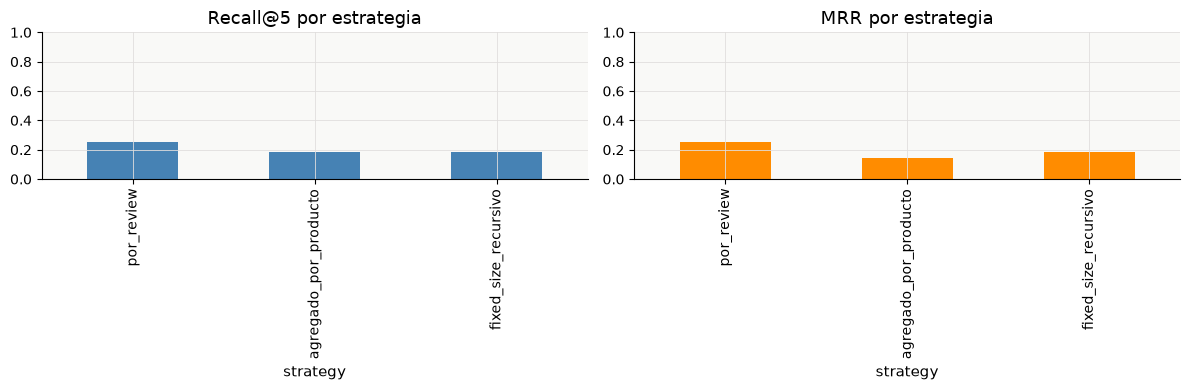

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df[f"recall@{TOP_K}"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title(f"Recall@{TOP_K} por estrategia")
axes[0].set_ylim(0, 1)

results_df["mrr"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("MRR por estrategia")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [48]:
results_df[["n_chunks", f"recall@{TOP_K}", "mrr"]]

,n_chunks,recall@5,mrr
strategy,,,
por_review,86565,0.2500,0.250000
agregado_por_producto,29080,0.1875,0.145833
fixed_size_recursivo,104440,0.1875,0.187500


### ¿Cómo definimos la estrategia ganadora?

- **Recall@k alto** = el producto correcto aparece entre los primeros k
  resultados casi siempre. Es la métrica más importante para un buscador.
- **MRR alto** = además de aparecer, aparece *arriba* en el ranking (no en el
  puesto 5 de 5).
- Miren también `n_chunks`: una estrategia puede ganar en métricas pero ser
  mucho más cara de indexar/mantener (más chunks = más costo de embeddings y
  de storage). Si dos estrategias empatan en métricas, gana la más liviana.

**Completar acá, con los números reales de la corrida:**
> Elegimos la estrategia `___` porque obtuvo Recall@`{TOP_K}` = `___` y
> MRR = `___`, superando a las demás en `___` puntos, con un costo de
> indexación de `___` chunks.

### Próximo paso
Una vez elegida la estrategia acá arriba, hay que correrla **una sola vez
sobre `df` completo** (no `df_experiment`) para generar los chunks reales que
van a alimentar al LLM:

```python
chunks_finales = chunk_fixed_size_recursive(df)  # reemplazar por la estrategia ganadora
collection_final = build_chroma_collection(chunks_finales, collection_name="reviews_final")
```

Con esos chunks, el LLM (con su `system prompt`) genera la descripción de
cada producto (paso 3 del documento de módulos). Esa descripción es la que
después se va a re-embeddear e indexar en Chroma para el buscador de cara al
usuario (capa 2).

# Indexación

In [37]:
N_TOP_PRODUCTS = 300  # ajustá según cuánto tarde en tu compu
top_ids = df.groupby("ProductId").size().sort_values(ascending=False).head(N_TOP_PRODUCTS).index
df_local = df[df["ProductId"].isin(top_ids)].copy()
print(f"Reviews a indexar: {len(df_local)} de {len(df)} totales")

# --- 3. Chunking (estrategia ganadora) ---
def make_chunk(product_id, text, extra_metadata=None):
    metadata = {"product_id": product_id}
    if extra_metadata:
        metadata.update(extra_metadata)
    return {"chunk_id": str(uuid.uuid4()), "product_id": product_id, "text": text, "metadata": metadata}

def chunk_by_review(df):
    chunks = []
    for row in tqdm(df.itertuples(), total=len(df), desc="Armando chunks"):
        chunks.append(make_chunk(
            row.ProductId, row.full_text,
            {"score": float(row.Score), "helpfulness_ratio": float(row.helpfulness_ratio)},
        ))
    return chunks

chunks_local = chunk_by_review(df_local)
print(f"Chunks generados: {len(chunks_local)}")

# --- 4. Embeddings en CPU (más lento que GPU, pero con este volumen es rápido igual) ---
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def embed_texts(texts, batch_size=64):
    return embedding_model.encode(texts, batch_size=batch_size, show_progress_bar=True).tolist()

# --- 5. Indexar en Chroma, persistente en tu compu ---
client = chromadb.PersistentClient(path="./chroma_db_local")
try:
    client.delete_collection("reviews_por_review_local")
except Exception:
    pass
collection = client.create_collection("reviews_por_review_local")

batch_size = 200
for i in tqdm(range(0, len(chunks_local), batch_size), desc="Indexando en Chroma"):
    batch = chunks_local[i:i + batch_size]
    collection.add(
        ids=[c["chunk_id"] for c in batch],
        documents=[c["text"] for c in batch],
        embeddings=embed_texts([c["text"] for c in batch]),
        metadatas=[c["metadata"] for c in batch],
    )

print(f"Total indexado: {collection.count()}")

Reviews a indexar: 97041 de 568454 totales


Armando chunks: 100%|██████████| 97041/97041 [00:00<00:00, 154455.21it/s]


Chunks generados: 97041


Indexando en Chroma: 100%|██████████| 486/486 [19:55<00:00,  2.46s/it]

Total indexado: 97041


In [38]:
print(collection.count())  # tiene que ser ~la cantidad de reviews de esos 300 productos

97041


In [39]:
def obtener_contexto_producto(product_id, collection, max_reviews=15):
    resultados = collection.get(
        where={"product_id": product_id},
        limit=max_reviews,
    )
    if not resultados["documents"]:
        return "", 0

    bloques = [
        f"- (Score {m['score']}/5) {doc}"
        for doc, m in zip(resultados["documents"], resultados["metadatas"])
    ]
    return "\n".join(bloques), len(resultados["documents"])

# Generación de Descripción de Productos

In [42]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "Falta definir OPENAI_API_KEY"
client = OpenAI()

SYSTEM_PROMPT = """Sos un asistente que redacta descripciones de productos \
de supermercado a partir de reviews reales de clientes.

Reglas estrictas:
1. Usá ÚNICAMENTE la información presente en las reviews que se te pasan. \
Nunca inventes ingredientes, certificaciones, usos o características que no \
estén mencionados explícitamente.
2. Si las reviews tienen opiniones contradictorias sobre algo, reflejá esa \
ambigüedad en vez de elegir una sola versión.
3. Si las reviews disponibles son muy pocas, escribí una descripción breve \
y aclará al final: "(Información limitada: pocas reviews disponibles)".
4. No uses lenguaje de marketing exagerado. Tono neutral e informativo.
5. Escribí en español, en 2 a 4 oraciones.
6. No menciones que la fuente son "reviews" ni "usuarios" en el texto final.
"""

In [43]:
import time

def generar_descripcion(product_id, collection, max_reviews=15, modelo="gpt-4o-mini", reintentos=3):
    contexto, n_reviews_usadas = obtener_contexto_producto(product_id, collection, max_reviews)
    if not contexto:
        return None, 0

    for intento in range(reintentos):
        try:
            response = client.chat.completions.create(
                model=modelo,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": f"Reviews del producto:\n{contexto}"},
                ],
                temperature=0.0,
                max_tokens=200,
            )
            return response.choices[0].message.content.strip(), n_reviews_usadas
        except Exception as e:
            print(f"Intento {intento+1} falló para {product_id}: {e}")
            time.sleep(2 ** intento)
    return None, n_reviews_usadas

In [47]:
import time
import os

CHECKPOINT_PATH = "descripciones_checkpoint.csv"

# si ya existe un checkpoint de una corrida anterior, lo cargamos y salteamos lo ya hecho
if os.path.exists(CHECKPOINT_PATH):
    df_descripciones = pd.read_csv(CHECKPOINT_PATH)
    ya_hechos = set(df_descripciones["product_id"])
else:
    df_descripciones = pd.DataFrame(columns=["product_id", "descripcion", "n_reviews_usadas"])
    ya_hechos = set()

pendientes = [pid for pid in top_ids if pid not in ya_hechos]
print(f"Ya generados: {len(ya_hechos)} | Pendientes: {len(pendientes)}")

resultados = []
for pid in tqdm(pendientes, desc="Generando descripciones"):
    descripcion, n_usadas = generar_descripcion(pid, collection)
    resultados.append({"product_id": pid, "descripcion": descripcion, "n_reviews_usadas": n_usadas})

    # guardamos cada 10 para no perder trabajo si el 429 diario corta el loop
    if len(resultados) % 10 == 0:
        df_temp = pd.concat([df_descripciones, pd.DataFrame(resultados)], ignore_index=True)
        df_temp.to_csv(CHECKPOINT_PATH, index=False)

    time.sleep(6.5)

df_descripciones = pd.concat([df_descripciones, pd.DataFrame(resultados)], ignore_index=True)
df_descripciones.to_csv(CHECKPOINT_PATH, index=False)
df_descripciones.head(10)

Ya generados: 0 | Pendientes: 300


Generando descripciones:  42%|████▏     | 127/300 [1:15:54<1:43:24, 35.86s/it]  


KeyboardInterrupt: 

In [49]:
df_descripciones

,product_id,descripcion,n_reviews_usadas


In [45]:
resultados = []
for pid in tqdm(top_ids, desc="Generando descripciones"):
    descripcion, n_usadas = generar_descripcion(pid, collection)
    resultados.append({"product_id": pid, "descripcion": descripcion, "n_reviews_usadas": n_usadas})

df_descripciones = pd.DataFrame(resultados)
df_descripciones.head(10)

Generando descripciones:  54%|█████▎    | 161/300 [05:57<05:15,  2.27s/it]

Intento 1 falló para B002GKEK7G: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-jw2C8pXpi83UxEPn2wvXXUpH on requests per day (RPD): Limit 50, Used 50, Requested 1. Please try again in 28m48s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}


Generando descripciones:  67%|██████▋   | 201/300 [07:39<03:36,  2.18s/it]

Intento 1 falló para B004TJF3BE: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-jw2C8pXpi83UxEPn2wvXXUpH on requests per day (RPD): Limit 50, Used 50, Requested 1. Please try again in 28m48s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}


Generando descripciones:  68%|██████▊   | 204/300 [07:49<04:33,  2.84s/it]

Intento 1 falló para B000NBQUNW: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-jw2C8pXpi83UxEPn2wvXXUpH on requests per day (RPD): Limit 50, Used 50, Requested 1. Please try again in 28m48s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}


Generando descripciones:  75%|███████▌  | 226/300 [08:50<02:56,  2.38s/it]

Intento 1 falló para B004391DK0: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-jw2C8pXpi83UxEPn2wvXXUpH on requests per min (RPM): Limit 10, Used 10, Requested 1. Please try again in 6s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}


Generando descripciones:  81%|████████▏ | 244/300 [09:45<02:14,  2.40s/it]


KeyboardInterrupt: 

In [46]:
df_descripciones.to_csv("descripciones_parciales.csv", index=False)

NameError: name 'df_descripciones' is not defined

## 3. Selección de chunks por producto (contexto para el LLM)

Para productos con cientos de reviews no tiene sentido (ni entra en el
contexto) mandar todas. Priorizamos por `helpfulness_ratio` y tomamos un
máximo, para que el LLM vea las opiniones más útiles/representativas.

In [ ]:
def obtener_contexto_producto(product_id, df, max_reviews=15):
    """Arma el bloque de texto con las reviews más útiles de un producto,
    para pasarle al LLM como contexto.
    """
    reviews_producto = df[df["ProductId"] == product_id].sort_values(
        "helpfulness_ratio", ascending=False
    ).head(max_reviews)

    bloques = [
        f"- (Score {int(row.Score)}/5) {row.full_text}"
        for row in reviews_producto.itertuples()
    ]
    return "\n".join(bloques), len(reviews_producto)


## 5. Validación en muestra chica antes de la corrida completa

**No corran esto todavía sobre los 74k productos.** Primero, sobre los
productos del golden set (los mismos 14 de siempre) + unos 30-50 más, para
revisar a mano si el prompt está funcionando bien.

In [ ]:
golden_set = [
    {"question": "What do customers say about the taste and texture of the oatmeal cookies?", "relevant_product_ids": ["B007JFMH8M"]},
    {"question": "Are there dog treats that help reduce nighttime coughing in older dogs?", "relevant_product_ids": ["B002QWP89S", "B002QWP8H0", "B002QWHJOU", "B0026RQTGE"]},
    {"question": "Which coconut oil is described as high quality and organic, good for popcorn?", "relevant_product_ids": ["B001EO5Q64"]},
    {"question": "What coconut oil is recommended for sweet dishes, like bread with honey?", "relevant_product_ids": ["B003B3OOPA"]},
    {"question": "What chips are a healthier, puffed alternative to regular potato chips?", "relevant_product_ids": ["B0026KPDG8", "B0026KNQSA", "B006HYLW32"]},
    {"question": "Are these dates good quality, with proper packaging and nutrition facts?", "relevant_product_ids": ["B000F9J43K"]},
    {"question": "Which dark chocolate is described as smooth and not too bitter?", "relevant_product_ids": ["B0009Z9FFW"]},
    {"question": "Is there a honey mustard mayonnaise sauce good for sandwiches?", "relevant_product_ids": ["B000EY7P96"]},
    {"question": "What dog food has no poultry by-products and is gentle on digestion?", "relevant_product_ids": ["B0018CIOJ8"]},
    {"question": "Is there a sweet cornbread mix that tastes almost like cake?", "relevant_product_ids": ["B001EO5QKA"]},
    {"question": "What spice mix works well for making Dal Makhani at home?", "relevant_product_ids": ["B002C2ROCG"]},
    {"question": "Is there a manuka honey good for tea that also boosts the immune system?", "relevant_product_ids": ["B002FBD3J2"]},
    {"question": "Which beef jerky has a soft texture with a honey chipotle flavor?", "relevant_product_ids": ["B0029JZNES"]},
    {"question": "Which product has complaints about receiving the wrong brand or vendor?", "relevant_product_ids": ["B002FBD3J2"]},
]

gold_ids = sorted(set(pid for item in golden_set for pid in item["relevant_product_ids"]))

# Sumamos 40 productos más al azar (con al menos 3 reviews, para no probar
# solo con casos triviales de 1 review)
counts = df.groupby("ProductId").size()
candidatos = counts[counts >= 3].index
muestra_extra = pd.Series(candidatos).sample(40, random_state=42).tolist()

productos_a_validar = list(dict.fromkeys(gold_ids + muestra_extra))  # sin duplicados, preserva orden
len(productos_a_validar)


In [ ]:
resultados_validacion = []

for pid in tqdm(productos_a_validar, desc="Generando descripciones (validación)"):
    descripcion, n_usadas = generar_descripcion(pid, df)
    resultados_validacion.append({
        "product_id": pid,
        "descripcion": descripcion,
        "n_reviews_usadas": n_usadas,
    })

df_validacion = pd.DataFrame(resultados_validacion)
df_validacion.head(15)


**Revisión manual — checklist antes de escalar:**
- Elegí 5-10 filas al azar de `df_validacion` y compará la descripción contra
  las reviews originales del producto (`df[df.ProductId == pid]`).
- ¿Hay algo afirmado que ninguna review dice? → ajustar prompt, ser más estricto.
- ¿Las descripciones son todas iguales de genéricas, sin nada distintivo del
  producto? → puede ser que `temperature` esté muy baja, o que el contexto
  que le llega sea muy poco (revisar `n_reviews_usadas`).
- ¿El caso de "información limitada" se activa cuando corresponde (productos
  con pocas reviews)?


## 7. De acá a la corrida completa: pasar a script con checkpointing

Si el prompt te convenció con la muestra, **no sigan corriendo la corrida
completa desde este notebook**. La idea de pasar a un script plano
(`generar_descripciones.py`) es que:

- Guarda cada descripción en la base relacional apenas se genera (no al
  final), así si se corta a la mitad no perdiste nada.
- Al reiniciarlo, salta automáticamente los `product_id` que ya tienen
  descripción guardada — no vuelve a gastar tokens de más.

Esqueleto de ese script (usando SQLite como base relacional simple, la que
sea más fácil como dice el doc):

```python
import sqlite3
import pandas as pd
from tqdm import tqdm
# ... importar generar_descripcion, SYSTEM_PROMPT, df igual que en este notebook

conn = sqlite3.connect("productos.db")
conn.execute("""
    CREATE TABLE IF NOT EXISTS descripciones (
        product_id TEXT PRIMARY KEY,
        descripcion TEXT,
        n_reviews_usadas INTEGER
    )
""")
conn.commit()

ya_procesados = {
    row[0] for row in conn.execute("SELECT product_id FROM descripciones")
}

todos_los_productos = df["ProductId"].unique()
pendientes = [pid for pid in todos_los_productos if pid not in ya_procesados]

print(f"Ya procesados: {len(ya_procesados)} | Pendientes: {len(pendientes)}")

for pid in tqdm(pendientes):
    descripcion, n_usadas = generar_descripcion(pid, df)
    if descripcion is not None:
        conn.execute(
            "INSERT OR REPLACE INTO descripciones VALUES (?, ?, ?)",
            (pid, descripcion, n_usadas),
        )
        conn.commit()  # commit por producto: más lento pero a prueba de cortes
```

Corriendo esto con `python generar_descripciones.py` en su compu local (no
hace falta notebook ni Colab para esta parte, es solo I/O de red), pueden
cortar el proceso en cualquier momento (`Ctrl+C`) y retomarlo después sin
duplicar trabajo ni gasto.

### Embedding
Con `productos.db` completo (tabla `descripciones`), el siguiente bloque es
el **paso 4 del documento**: embeddear cada `descripcion` y cargarla en
Chroma, para armar el retrieval de cara al usuario (capa 2) que ya diseñamos
en el notebook de chunking.

In [3]:
import os
import pandas as pd

CHECKPOINT_PATH = "descripciones_checkpoint.csv"
PARCIAL_PATH = "descripciones_parciales.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_descripciones = pd.read_csv(CHECKPOINT_PATH)
elif os.path.exists(PARCIAL_PATH):
    df_descripciones = pd.read_csv(PARCIAL_PATH)
else:
    df_descripciones = pd.DataFrame(columns=["product_id", "descripcion", "n_reviews_usadas"])

if "descripcion" in df_descripciones.columns:
    df_descripciones["descripcion"] = df_descripciones["descripcion"].fillna("")
if "n_reviews_usadas" in df_descripciones.columns:
    df_descripciones["n_reviews_usadas"] = pd.to_numeric(
        df_descripciones["n_reviews_usadas"], errors="coerce"
    ).fillna(0).astype(int)

print(f"Descripciones cargadas: {len(df_descripciones)}")
print(f"Longitud promedio de descripción: {round(df_descripciones['descripcion'].str.len().mean(), 1)}")
print("\nDistribución de reviews usadas:")
print(df_descripciones["n_reviews_usadas"].value_counts().sort_index())

df_descripciones.head(10)


Descripciones cargadas: 120
Longitud promedio de descripción: 593.6

Distribución de reviews usadas:
n_reviews_usadas
15    120
Name: count, dtype: int64


,product_id,descripcion,n_reviews_usadas
0,B007JFMH8M,Las Galletas de Avena y Pasas Quaker Soft Bake...,15
1,B002QWP8H0,Los Greenies son un popular tratamiento dental...,15
2,B002QWHJOU,Los Greenies son un popular tratamiento dental...,15
3,B002QWP89S,Los Greenies son un popular tratamiento dental...,15
4,B0026RQTGE,Los Greenies son un popular tratamiento dental...,15
5,B003B3OOPA,El aceite de coco de Nature's Way es un produc...,15
6,B001EO5Q64,El aceite de coco Nutiva es un producto versát...,15
7,B006HYLW32,Popchips son una alternativa de snack que se d...,15
8,B001RVFERK,Popchips son una alternativa de snack que se d...,15
9,B001RVFEP2,Popchips son una alternativa más saludable a l...,15


In [4]:
# Revisar ejemplos concretos para detectar descripciones demasiado genéricas o poco precisas
for pid in df_descripciones["product_id"].head(10).tolist():
    row = df_descripciones[df_descripciones["product_id"] == pid].iloc[0]
    print(f"\n=== {pid} ===")
    print(row["descripcion"])
    print("-" * 80)



=== B007JFMH8M ===
Las Galletas de Avena y Pasas Quaker Soft Baked son un snack suave y delicioso, ideal para cualquier momento del día. Con una textura blanda y masticable, cada galleta está individualmente empaquetada y contiene sabores naturales como canela y especias. Aunque tienen 170 calorías por galleta, muchos las consideran una opción satisfactoria y saludable, especialmente para los niños. Su sabor y calidad han sido bien recibidos, convirtiéndolas en una opción popular para quienes buscan un dulce más nutritivo. 

(Información limitada: pocas reviews disponibles)
--------------------------------------------------------------------------------

=== B002QWP8H0 ===
Los Greenies son un popular tratamiento dental para perros que muchos dueños consideran efectivos para mejorar el aliento y la salud dental de sus mascotas. Vienen en diferentes tamaños, siendo el tamaño Teenie adecuado para perros pequeños. Sin embargo, algunos usuarios han reportado que ciertos perros pueden traga

In [5]:
# Prompt mejorado para generar descripciones más concretas y menos genéricas
SYSTEM_PROMPT_MEJORADO = """Sos un asistente que redacta descripciones breves y precisas de productos de supermercado a partir de reviews reales.

Reglas:
1. Usa solo la información presente en las reviews.
2. Destaca 2 o 3 atributos concretos: sabor, textura, uso, empaque, precio, ingredientes o problemas frecuentes.
3. Si hay opiniones contradictorias, menciona esa ambigüedad de forma breve.
4. Escribe en español, en 1 o 2 oraciones, con tono neutral y claro.
5. Evita frases vacías como "es una opción popular" o "muy valorado".
6. Si la información es limitada, agrega al final: "(Información limitada: pocas reviews disponibles)".
"""

SYSTEM_PROMPT_MEJORADO

'Sos un asistente que redacta descripciones breves y precisas de productos de supermercado a partir de reviews reales.\n\nReglas:\n1. Usa solo la información presente en las reviews.\n2. Destaca 2 o 3 atributos concretos: sabor, textura, uso, empaque, precio, ingredientes o problemas frecuentes.\n3. Si hay opiniones contradictorias, menciona esa ambigüedad de forma breve.\n4. Escribe en español, en 1 o 2 oraciones, con tono neutral y claro.\n5. Evita frases vacías como "es una opción popular" o "muy valorado".\n6. Si la información es limitada, agrega al final: "(Información limitada: pocas reviews disponibles)".\n'

In [ ]:
# Crear un lookup de nombres inferidos por ProductId y unirlo al dataframe principal
if "product_name_inferred" not in df.columns:
    product_ids = df["ProductId"].dropna().unique()
    product_name_map = {
        pid: infer_product_name(pid, df, max_reviews=10)
        for pid in product_ids
    }
    df["product_name_inferred"] = df["ProductId"].map(product_name_map)

name_lookup = (
    df[["ProductId", "product_name_inferred"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

if "product_name_inferred" in df.columns:
    df = df.drop(columns=["product_name_inferred"])

# Merge al dataframe principal

df = df.merge(name_lookup, on="ProductId", how="left")

print(df[["ProductId", "product_name_inferred"]].drop_duplicates().head(10))
